In [1]:
# Imports + Load Original DF
import os, random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

2025-12-12 10:48:34.999939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-12 10:48:35.015609: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765536515.033955   11943 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765536515.039847   11943 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765536515.056476   11943 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

   actor gender  emotion emotion_lb  \
0      1   male        1    neutral   
1      1   male        1    neutral   
2      1   male        1    neutral   
3      1   male        1    neutral   
4      1   male        2       calm   

                                                path  dataset  length_sec  \
0  Data/Processed_Audio/Actor_01/03-01-01-01-01-0...  RAVDESS       1.344   
1  Data/Processed_Audio/Actor_01/03-01-01-01-01-0...  RAVDESS       1.312   
2  Data/Processed_Audio/Actor_01/03-01-01-01-02-0...  RAVDESS       1.280   
3  Data/Processed_Audio/Actor_01/03-01-01-01-02-0...  RAVDESS       1.280   
4  Data/Processed_Audio/Actor_01/03-01-02-01-01-0...  RAVDESS       1.568   

   sentiment sentiment_name  
0          1       Moderate  
1          1       Moderate  
2          1       Moderate  
3          1       Moderate  
4          1       Moderate  
sentiment
0    8244
2    2759
1    2171
Name: count, dtype: int64


C:\Users\helen\AppData\Local\Temp\ipykernel_11708\1983152500.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment_name", palette=["green", "gray", "red"])


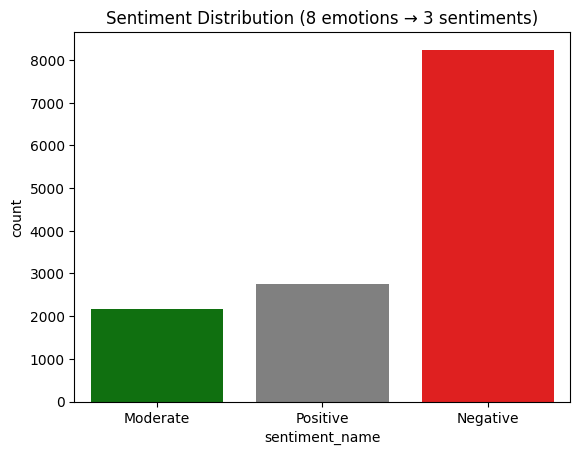

In [17]:
# Sentiment Distribution
df = pd.read_csv("DataFrame/processed_df.csv")

# Map emotion labels to sentiment groups
emotion_to_sentiment = {
    "angry": -1,
    "fearful": -1,
    "disgust": -1,
    "sad": -1,
    "neutral": 0,
    "calm": 0,
    "happy": 1,
    "surprised": 1
}

# Derive sentiment, clean, remap to [0,1,2]
df["sentiment"] = df["emotion_lb"].map(emotion_to_sentiment)
df = df.dropna(subset=["sentiment"])
df["sentiment"] = df["sentiment"].astype(int)
df["sentiment"] = df["sentiment"].map({-1: 0, 0: 1, 1: 2}).astype(int)

# Normalize paths for Linux/Windows
df["path"] = df["path"].str.replace("\\", "/", regex=False)

sentiment_label_map = {0: "Negative", 1: "Moderate", 2: "Positive"}
df["sentiment_name"] = df["sentiment"].map(sentiment_label_map)

df.to_csv("DataFrame/processed_sentiment_df.csv", index=False)

print(df.head())
print(df["sentiment"].value_counts())

sns.countplot(data=df, x="sentiment_name", palette=["green", "gray", "red"])
plt.title("Sentiment Distribution (8 emotions → 3 sentiments)")
plt.show()


In [18]:
df[df["sentiment"].isna()][["emotion_lb"]].value_counts()


Series([], Name: count, dtype: int64)

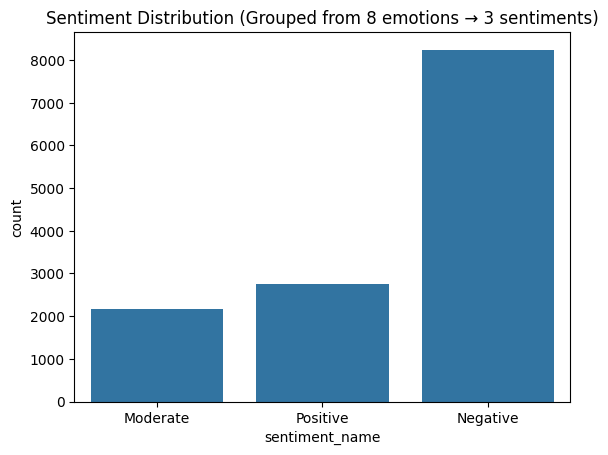

In [19]:
sns.countplot(data=df, x="sentiment_name")
plt.title("Sentiment Distribution (Grouped from 8 emotions → 3 sentiments)")
plt.show()

In [20]:
def pitch_shift(y, sr=16000):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=random.choice([-2, -1, 1, 2]))

def time_stretch(y):
    rate = random.choice([0.8, 0.9, 1.1, 1.2])
    return librosa.effects.time_stretch(y=y, rate=rate)

def add_noise(y):
    noise = np.random.normal(0, 0.01, y.shape)
    return y + noise

AUG_FUNCS = [pitch_shift, time_stretch, add_noise]

def augment_audio(y, sr=16000):
    func = random.choice(AUG_FUNCS)
    return func(y)

In [ ]:
from tqdm import tqdm
import random
def create_balanced_sentiment(df):
    # Fix Windows → Linux paths
    df["path"] = df["path"].str.replace("\\", "/", regex=False)

    groups = df.groupby("sentiment")
    max_size = groups.size().max()

    augmented_rows = []

    print("Balancing sentiment groups...\n")

    for s, group in groups:
        count = len(group)
        need = max_size - count

        print(f"\n Sentiment: {s}")
        print(f"   Current samples: {count}")
        print(f"   Need to generate: {need}")

        if need <= 0:
            augmented_rows.append(group)
            continue

        # Choose rows that will be augmented
        sample = group.sample(need, replace=True)

        # Progress bar for augmentation
        for _, row in tqdm(sample.iterrows(), 
                           total=len(sample),
                           desc=f"Augmenting {s}", 
                           leave=True):

            if not os.path.exists(row["path"]):
                print(f"⚠ Missing file: {row['path']}")
                continue

            # Load audio
            y, sr = librosa.load(row["path"], sr=16000)

            # Apply augmentation
            y_aug = augment_audio(y)

            # Save augmented file
            new_path = row["path"].replace(".wav", f"_aug_{random.randint(1,99999)}.wav")
            sf.write(new_path, y_aug, sr)

            # Add row to dataset
            new_row = row.copy()
            new_row["path"] = new_path
            augmented_rows.append(pd.DataFrame([new_row]))

        augmented_rows.append(group)

    df_final = pd.concat(augmented_rows, ignore_index=True)
    df_final.to_csv("DataFrame/processed_sentiment_balanced.csv", index=False)

    print("\nBalanced dataset saved to: DataFrame/processed_sentiment_balanced.csv")
    print(f"Final dataset size: {len(df_final)} samples")

    return df_final

# Run
df_bal = create_balanced_sentiment(df)
df_bal = df.groupby("sentiment", group_keys=False).apply(
    lambda x: x.sample(df["sentiment"].value_counts().max(), replace=True)
).reset_index(drop=True)

Balancing sentiment groups...


 Sentiment: 0
   Current samples: 8244
   Need to generate: 0

 Sentiment: 1
   Current samples: 2171
   Need to generate: 6073


Augmenting 1: 100%|██████████| 6073/6073 [01:19<00:00, 76.34it/s] 



 Sentiment: 2
   Current samples: 2759
   Need to generate: 5485


Augmenting 2: 100%|██████████| 5485/5485 [01:11<00:00, 76.22it/s] 



Balanced dataset saved to: DataFrame/processed_sentiment_balanced.csv
Final dataset size: 24732 samples


In [24]:
def apply_cmvn(y):
    mean = np.mean(y)
    std = np.std(y) + 1e-8
    return (y - mean) / std


In [25]:
import torch
from torch.utils.data import Dataset

class SERDataset(Dataset):
    def __init__(self, df, extractor):
        self.df = df
        self.extractor = extractor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, sr = librosa.load(row["path"], sr=16000)
        y = apply_cmvn(y)

        inputs = self.extractor(
            y,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values": inputs["input_values"][0],
            "labels": torch.tensor(row["sentiment"], dtype=torch.long)
        }


In [26]:
from sklearn.model_selection import train_test_split

# Feature extractor (needed before dataset creation)
extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")

train_df, test_df = train_test_split(df_bal, test_size=0.2, stratify=df_bal["sentiment"], random_state=42)

train_dataset = SERDataset(train_df, extractor)
test_dataset  = SERDataset(test_df, extractor)


d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


In [ ]:
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Reuse extractor if already loaded; otherwise load
extractor = extractor if "extractor" in locals() else AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")

# Model with explicit label mapping
model = AutoModelForAudioClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=3,
    label2id={0: 0, 1: 1, 2: 2},
    id2label={0: "Negative", 1: "Moderate", 2: "Positive"},
    ignore_mismatched_sizes=True
)

# Data collator for variable-length audio
data_collator = DataCollatorWithPadding(
    tokenizer=extractor,
    padding=True
)

# Training args
training_args = TrainingArguments(
    output_dir="Models/Sentiment_Model",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    num_train_epochs=20,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    load_best_model_at_end=False
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator
)

# Train
trainer.train()

# Save final model
model.save_pretrained("Models/Sentiment_Model/final_model")
extractor.save_pretrained("Models/Sentiment_Model/final_model")

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
import numpy as np
import json

# Prediction
pred = trainer.predict(test_dataset)
y_true = pred.label_ids
y_prob = pred.predictions
y_pred = np.argmax(y_prob, axis=1)

# Save metrics
metrics = trainer.evaluate()
with open("Models/Sentiment_Model/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Classification report
report = classification_report(y_true, y_pred, target_names=["Negative","Moderate","Positive"], output_dict=True)
pd.DataFrame(report).to_csv("Models/Sentiment_Model/classification_report.csv")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative","Moderate","Positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("Models/Sentiment_Model/confusion_matrix.png")
plt.close()

# ROC Curve (one-vs-rest)
plt.figure(figsize=(7,5))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true == i, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.3f}")

plt.title("Sentiment ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("Models/Sentiment_Model/roc_curve.png")
plt.close()


In [ ]:
# 8 — Evaluation
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

y_true, y_pred, y_prob = [], [], []

for batch in datasets["test"]:
    inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items() if k != "labels"}
    label = batch["labels"]

    with torch.no_grad():
        logits = model(**inputs).logits
        prob = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred = prob.argmax()

    y_true.append(label)
    y_pred.append(pred)
    y_prob.append(prob)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Negative","Moderate","Positive"]))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Neg","Mod","Pos"]).plot(cmap="Blues")
plt.show()


In [ ]:
log_history = trainer.state.log_history
train_loss = [e["loss"] for e in log_history if "loss" in e]
eval_loss  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=[0,1,2])
y_prob = np.array(y_prob)

plt.figure(figsize=(8,6))
for i, label in enumerate(["Neg","Mod","Pos"]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"k--")
plt.legend()
plt.title("ROC Curves")
plt.show()
